LOADING DATASET
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0             0.00            0.00  ...           0

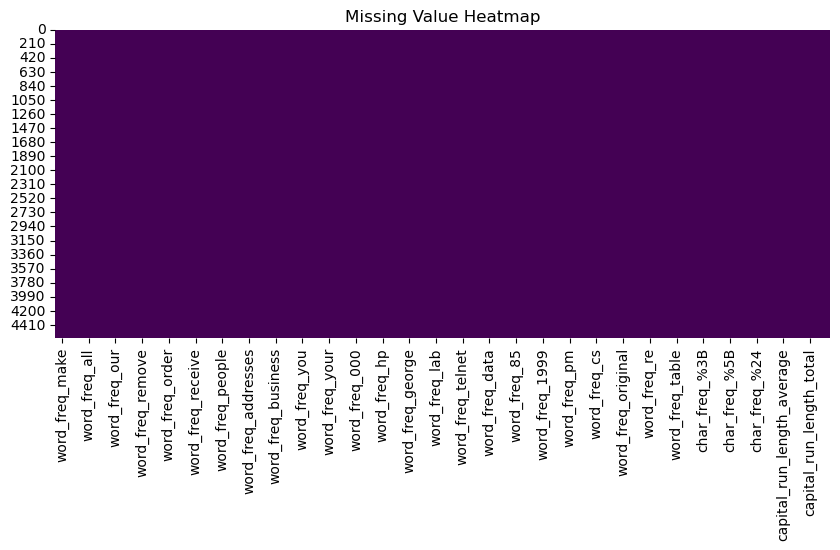



VISUALIZATION


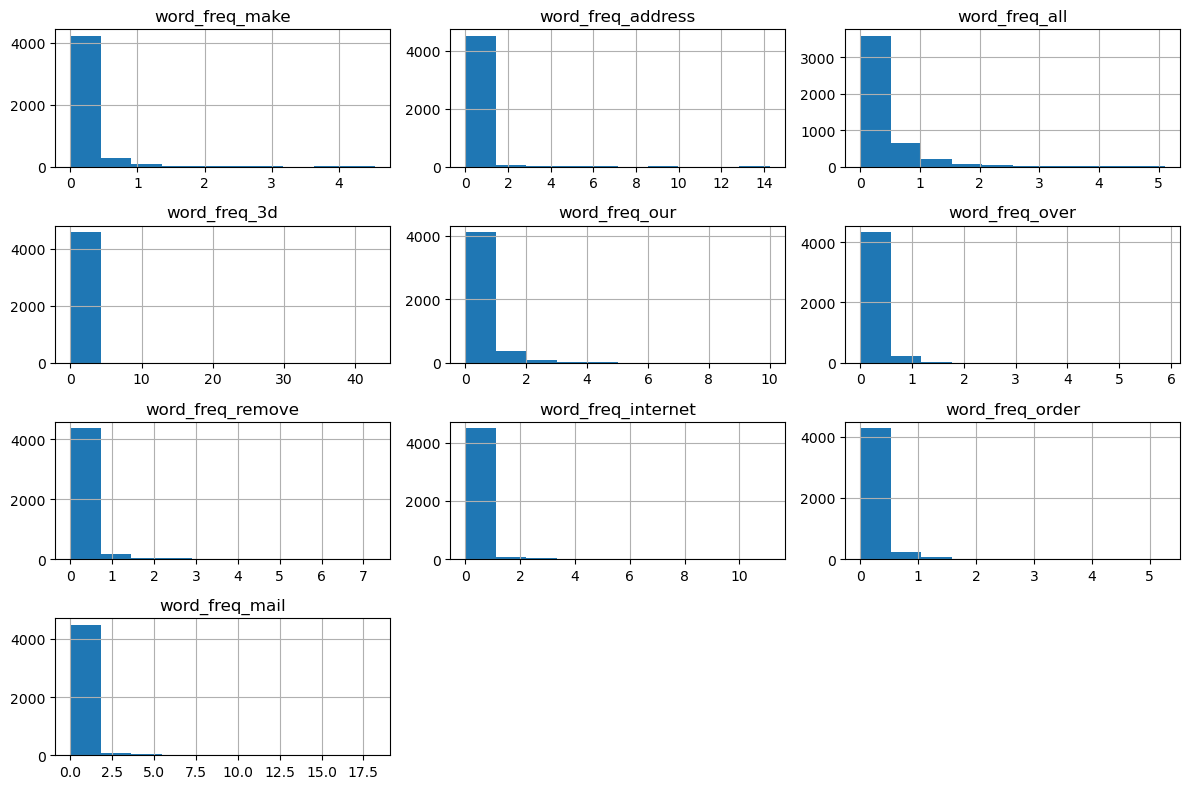

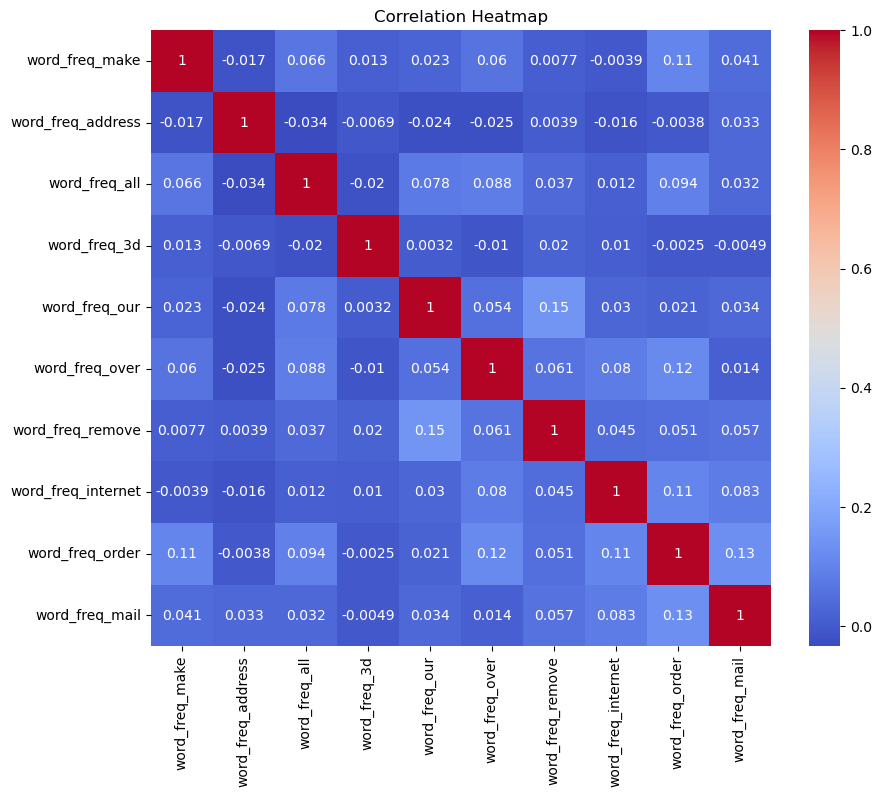


Pair Plot skipped because dataset has many features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def detect_task_type(df, target_column, unique_threshold=20):

    target_dtype = df[target_column].dtype
    n_unique = df[target_column].nunique()

    print(f"\nTarget column: {target_column}")
    print(f"Data type: {target_dtype}")
    print(f"Unique values: {n_unique}")

    if target_dtype == "object" or target_dtype.name == "category":
        task_type = "Classification"
        reason = "Target is categorical"

    elif n_unique <= unique_threshold:
        task_type = "Classification"
        reason = "Numeric target with few unique values"

    else:
        task_type = "Regression"
        reason = "Continuous numeric target"

    print("\nDetected Task :", task_type)
    print("Reason :", reason)

    return task_type


def eda_process(filepath, target_column):

    print("="*60)
    print("LOADING DATASET")
    print("="*60)

    df = pd.read_csv(filepath)

    print(df.head())

    print("\nShape :", df.shape)

    print("\nData Types")
    print(df.dtypes)

    print("\n")
    print("="*60)
    print("TASK TYPE")
    print("="*60)

    task = detect_task_type(df, target_column)

    print("\n")
    print("="*60)
    print("SUMMARY")
    print("="*60)

    print(df.describe())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows :", df.duplicated().sum())

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if target_column in numeric_cols:
        numeric_cols.remove(target_column)

    plt.figure(figsize=(10,4))
    sns.heatmap(df.isnull(),
                cbar=False,
                cmap="viridis")
    plt.title("Missing Value Heatmap")
    plt.show()

    print("\n")
    print("="*60)
    print("VISUALIZATION")
    print("="*60)

    plot_cols = numeric_cols[:10]

    df[plot_cols].hist(figsize=(12,8))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,8))
    sns.heatmap(df[plot_cols].corr(),
                annot=True,
                cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    print("\nPair Plot skipped because dataset has many features.")

    return df, task


df_spam, task = eda_process(
    filepath="spambase.csv",
    target_column="class"
)

DATA PREPROCESSING

Handling Missing Values
0 missing values remaining

Handling Outliers

Outliers in each column
{'word_freq_make': np.int64(1053), 'word_freq_address': np.int64(898), 'word_freq_all': np.int64(338), 'word_freq_3d': np.int64(47), 'word_freq_our': np.int64(501), 'word_freq_over': np.int64(999), 'word_freq_remove': np.int64(807), 'word_freq_internet': np.int64(824), 'word_freq_order': np.int64(773), 'word_freq_mail': np.int64(852), 'word_freq_receive': np.int64(709), 'word_freq_will': np.int64(270), 'word_freq_people': np.int64(852), 'word_freq_report': np.int64(357), 'word_freq_addresses': np.int64(336), 'word_freq_free': np.int64(957), 'word_freq_business': np.int64(963), 'word_freq_email': np.int64(1038), 'word_freq_you': np.int64(75), 'word_freq_credit': np.int64(424), 'word_freq_your': np.int64(229), 'word_freq_font': np.int64(117), 'word_freq_000': np.int64(679), 'word_freq_money': np.int64(735), 'word_freq_hp': np.int64(1090), 'word_freq_hpl': np.int64(811), 'wor

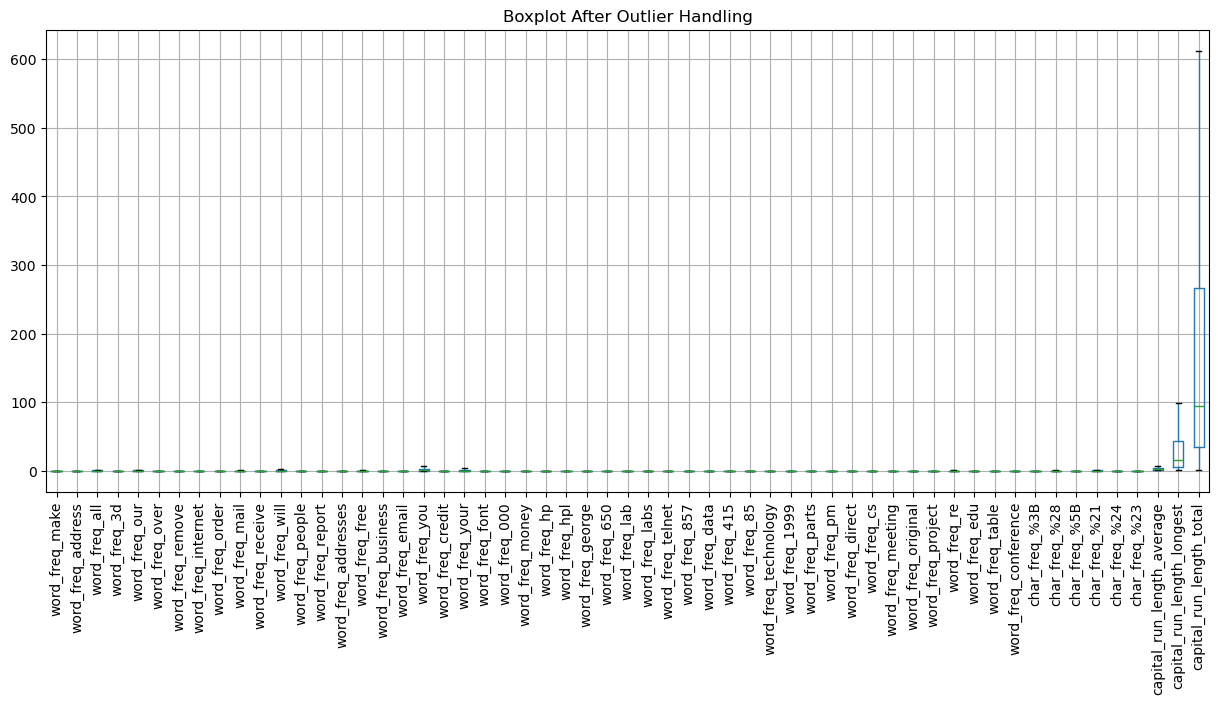


Normalizing Features

Normalization Completed


In [2]:
from sklearn.preprocessing import StandardScaler

def preprocessing_process(df, target_column):

    print("="*60)
    print("DATA PREPROCESSING")
    print("="*60)

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if target_column in numeric_cols:
        numeric_cols.remove(target_column)

    # Handle Missing Values
    print("\nHandling Missing Values")

    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    print(df.isnull().sum().sum(), "missing values remaining")

    # Handle Outliers
    print("\nHandling Outliers")

    outlier_summary = {}

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        outlier_summary[col] = outliers

        df[col] = df[col].clip(lower, upper)

    print("\nOutliers in each column")
    print(outlier_summary)

    # Boxplot
    plt.figure(figsize=(15,6))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After Outlier Handling")
    plt.show()

    # Split Features and Target
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Normalize Features
    print("\nNormalizing Features")

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    X_scaled = pd.DataFrame(
        X_scaled,
        columns=X.columns,
        index=X.index
    )

    print("\nNormalization Completed")

    return X_scaled, y


X, y = preprocessing_process(
    df_spam,
    target_column="class"
)

In [3]:
from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.2, random_state=42):

    print("="*60)
    print("TRAIN TEST SPLIT")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print(f"X_train Shape : {X_train.shape}")
    print(f"X_test Shape  : {X_test.shape}")
    print(f"y_train Shape : {y_train.shape}")
    print(f"y_test Shape  : {y_test.shape}")

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(X, y)

TRAIN TEST SPLIT
X_train Shape : (3680, 57)
X_test Shape  : (921, 57)
y_train Shape : (3680,)
y_test Shape  : (921,)


In [24]:
import time

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import MinMaxScaler


# Create non-negative data only for MultinomialNB
minmax = MinMaxScaler()

X_train_multi = minmax.fit_transform(X_train)
X_test_multi = minmax.transform(X_test)


def train_model(model_name, X_train, X_test, y_train, y_test):

    if model_name == "GaussianNB":
        model = GaussianNB()

    elif model_name == "MultinomialNB":
        model = MultinomialNB()

    elif model_name == "BernoulliNB":
        model = BernoulliNB()

    elif model_name == "KNN":
        model = KNeighborsClassifier(n_neighbors=5)

    else:
        print("Invalid Model")
        return None

    # Training Time
    start = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start

    # Prediction Time
    start = time.time()

    y_pred = model.predict(X_test)

    prediction_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy          : {accuracy*100:.2f}%")
    print(f"Training Time     : {training_time:.6f} seconds")
    print(f"Prediction Time   : {prediction_time:.6f} seconds")

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    return model, accuracy, training_time, prediction_time

In [25]:
gaussian_model, gaussian_accuracy, gaussian_train, gaussian_predict = train_model(
    "GaussianNB",
    X_train,
    X_test,
    y_train,
    y_test
)

multinomial_model,multinomial_accuracy, multinomial_train, multinomial_predict = train_model(
    "MultinomialNB",
    X_train_multi,
    X_test_multi,
    y_train,
    y_test
)

bernoulli_model,bernoulli_accuracy, bernoulli_train,bernoulli_predict = train_model(
    "BernoulliNB",
    X_train,
    X_test,
    y_train,
    y_test
)

knn_model,knn_accuracy,knn_train,knn_predict = train_model(
    "KNN",
    X_train,
    X_test,
    y_train,
    y_test
)

GaussianNB
Accuracy          : 85.78%
Training Time     : 0.027241 seconds
Prediction Time   : 0.006420 seconds

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       558
           1       0.79      0.87      0.83       363

    accuracy                           0.86       921
   macro avg       0.85      0.86      0.85       921
weighted avg       0.86      0.86      0.86       921

Confusion Matrix
[[473  85]
 [ 46 317]]
MultinomialNB
Accuracy          : 85.78%
Training Time     : 0.008694 seconds
Prediction Time   : 0.001341 seconds

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       558
           1       0.84      0.79      0.81       363

    accuracy                           0.86       921
   macro avg       0.85      0.85      0.85       921
weighted avg       0.86      0.86      0.86       921

Confusion Matrix
[[504  54]
 [ 77

In [35]:
import time

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

def grid_search_knn(X_train, y_train):

    print("="*70)
    print("GRID SEARCH CV")
    print("="*70)

    param_grid = {

        "n_neighbors":[1,3,5,7,9,11],

        "metric":["euclidean",
                  "manhattan",
                  "minkowski"],

        "weights":["uniform",
                   "distance"],

        "algorithm":["auto",
                     "ball_tree",
                     "kd_tree"]

    }

    model = KNeighborsClassifier()

    start = time.time()

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        cv=5,

        scoring="accuracy",

        n_jobs=-1

    )

    grid.fit(X_train,y_train)

    execution_time = time.time()-start

    print("\nBest Parameters")
    print("----------------------------")
    print("Best k          :",grid.best_params_["n_neighbors"])
    print("Metric          :",grid.best_params_["metric"])
    print("Weights         :",grid.best_params_["weights"])
    print("Algorithm       :",grid.best_params_["algorithm"])
    print("CV Accuracy     : {:.4f}".format(grid.best_score_))
    print("Execution Time  : {:.4f} seconds".format(execution_time))

    return grid

In [36]:
def random_search_knn(X_train,y_train):

    print("="*70)
    print("RANDOMIZED SEARCH CV")
    print("="*70)

    param_dist={

        "n_neighbors":range(1,31),

        "metric":["euclidean",
                  "manhattan",
                  "minkowski"],

        "weights":["uniform",
                   "distance"],

        "algorithm":["auto",
                     "ball_tree",
                     "kd_tree"]

    }

    model=KNeighborsClassifier()

    start=time.time()

    random=RandomizedSearchCV(

        estimator=model,

        param_distributions=param_dist,

        n_iter=20,

        cv=5,

        scoring="accuracy",

        random_state=42,

        n_jobs=-1

    )

    random.fit(X_train,y_train)

    execution_time=time.time()-start

    print("\nBest Parameters")
    print("----------------------------")
    print("Best k          :",random.best_params_["n_neighbors"])
    print("Metric          :",random.best_params_["metric"])
    print("Weights         :",random.best_params_["weights"])
    print("Algorithm       :",random.best_params_["algorithm"])
    print("CV Accuracy     : {:.4f}".format(random.best_score_))
    print("Execution Time  : {:.4f} seconds".format(execution_time))

    return random

In [37]:
grid = grid_search_knn(X_train, y_train)

print()

random = random_search_knn(X_train, y_train)

GRID SEARCH CV

Best Parameters
----------------------------
Best k          : 11
Metric          : manhattan
Weights         : distance
Algorithm       : auto
CV Accuracy     : 0.9141
Execution Time  : 105.7655 seconds

RANDOMIZED SEARCH CV

Best Parameters
----------------------------
Best k          : 9
Metric          : manhattan
Weights         : distance
Algorithm       : auto
CV Accuracy     : 0.9133
Execution Time  : 18.0280 seconds


In [10]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def compare_kdtree_balltree(X_train, X_test, y_train, y_test):

    print("="*80)
    print("KDTree vs BallTree")
    print("="*80)

    algorithms = ["kd_tree", "ball_tree"]

    print(f"{'Algorithm':<15}{'Accuracy':<15}{'Training Time':<20}{'Prediction Time':<20}")
    print("-"*80)

    for algo in algorithms:

        model = KNeighborsClassifier(
            n_neighbors=5,
            algorithm=algo
        )

        start = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start

        start = time.time()
        y_pred = model.predict(X_test)
        prediction_time = time.time() - start

        accuracy = accuracy_score(y_test, y_pred)

        print(f"{algo:<15}{accuracy*100:<15.2f}{training_time:<20.6f}{prediction_time:<20.6f}")


compare_kdtree_balltree(
    X_train,
    X_test,
    y_train,
    y_test
)

KDTree vs BallTree
Algorithm      Accuracy       Training Time       Prediction Time     
--------------------------------------------------------------------------------
kd_tree        89.14          0.042971            0.125738            
ball_tree      89.14          0.013983            0.220013            


In [11]:
from sklearn.model_selection import cross_val_score

def perform_cross_validation(model, X, y):

    print("="*70)
    print("5 FOLD CROSS VALIDATION")
    print("="*70)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    for i, score in enumerate(scores, start=1):
        print(f"Fold {i} Accuracy : {score:.4f}")

    print("\nAverage Accuracy :", scores.mean())

perform_cross_validation(
    KNeighborsClassifier(n_neighbors=5),
    X,
    y
)

5 FOLD CROSS VALIDATION
Fold 1 Accuracy : 0.8860
Fold 2 Accuracy : 0.8902
Fold 3 Accuracy : 0.9120
Fold 4 Accuracy : 0.9163
Fold 5 Accuracy : 0.8065

Average Accuracy : 0.8821986970684039


In [12]:
def calculate_time(model, X_train, X_test, y_train):

    print("="*70)
    print(type(model).__name__)
    print("="*70)

    start = time.time()

    model.fit(X_train, y_train)

    training_time = time.time() - start

    start = time.time()

    model.predict(X_test)

    prediction_time = time.time() - start

    print(f"Training Time  : {training_time:.6f} seconds")
    print(f"Prediction Time: {prediction_time:.6f} seconds")

calculate_time(
    GaussianNB(),
    X_train,
    X_test,
    y_train
)

calculate_time(
    MultinomialNB(),
    X_train_multi,
    X_test_multi,
    y_train
)

calculate_time(
    BernoulliNB(),
    X_train,
    X_test,
    y_train
)

calculate_time(
    KNeighborsClassifier(),
    X_train,
    X_test,
    y_train
)

GaussianNB
Training Time  : 0.011468 seconds
Prediction Time: 0.002347 seconds
MultinomialNB
Training Time  : 0.006635 seconds
Prediction Time: 0.001460 seconds
BernoulliNB
Training Time  : 0.023572 seconds
Prediction Time: 0.002216 seconds
KNeighborsClassifier
Training Time  : 0.005726 seconds
Prediction Time: 0.063013 seconds


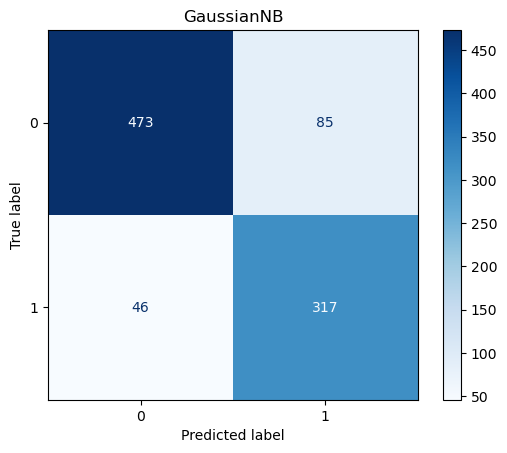

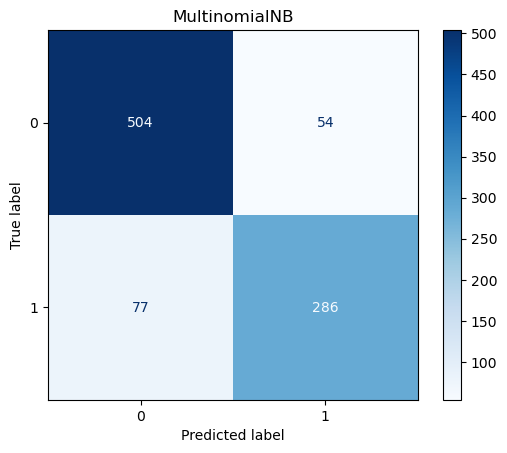

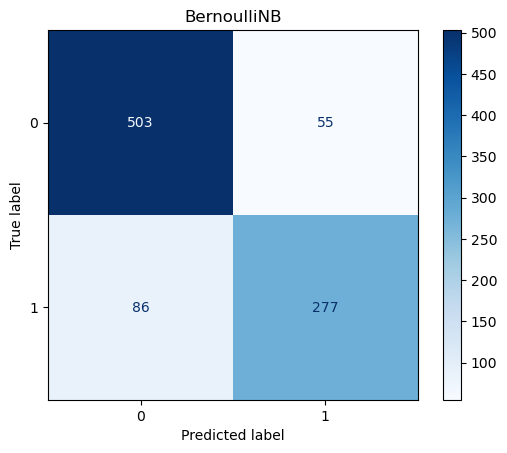

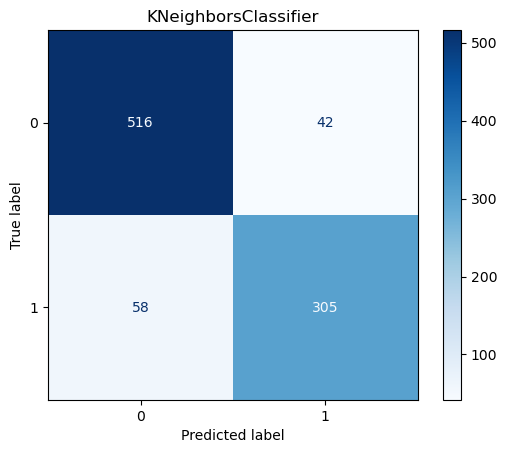

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluation_plot(model, X_test, y_test):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(type(model).__name__)
    plt.show()

evaluation_plot(
    gaussian_model,
    X_test,
    y_test
)

evaluation_plot(
    multinomial_model,
    X_test_multi,
    y_test
)

evaluation_plot(
    bernoulli_model,
    X_test,
    y_test
)

evaluation_plot(
    knn_model,
    X_test,
    y_test
)

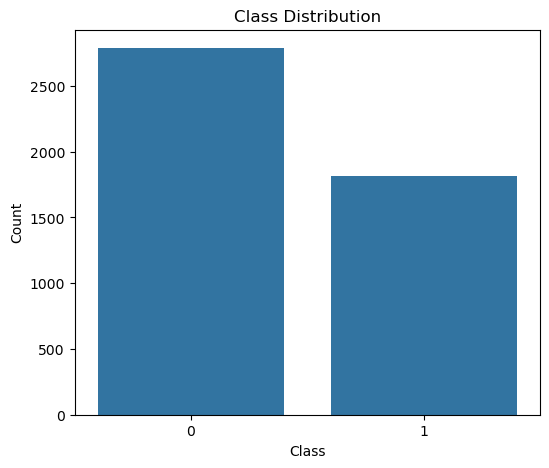

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x=df_spam["class"])

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

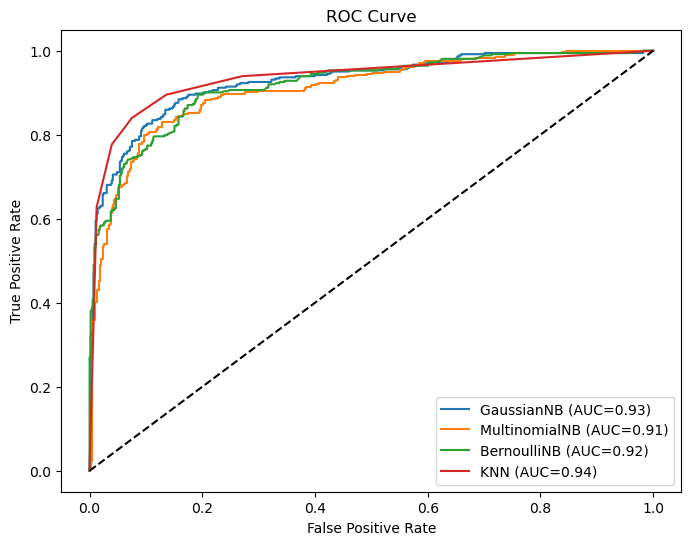

In [15]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "GaussianNB": gaussian_model,
    "MultinomialNB": multinomial_model,
    "BernoulliNB": bernoulli_model,
    "KNN": knn_model
}

for name, model in models.items():

    if name == "MultinomialNB":
        y_score = model.predict_proba(X_test_multi)[:,1]
    else:
        y_score = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,y_score)

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

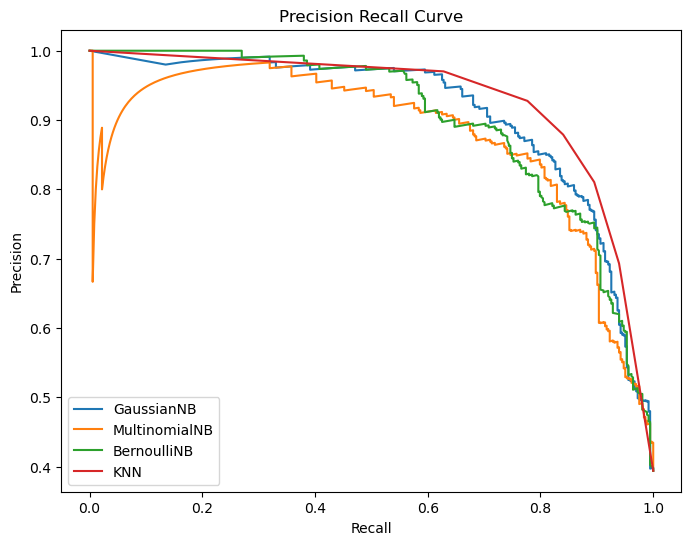

In [16]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name,model in models.items():

    if name=="MultinomialNB":
        y_score=model.predict_proba(X_test_multi)[:,1]
    else:
        y_score=model.predict_proba(X_test)[:,1]

    precision,recall,_=precision_recall_curve(y_test,y_score)

    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.show()

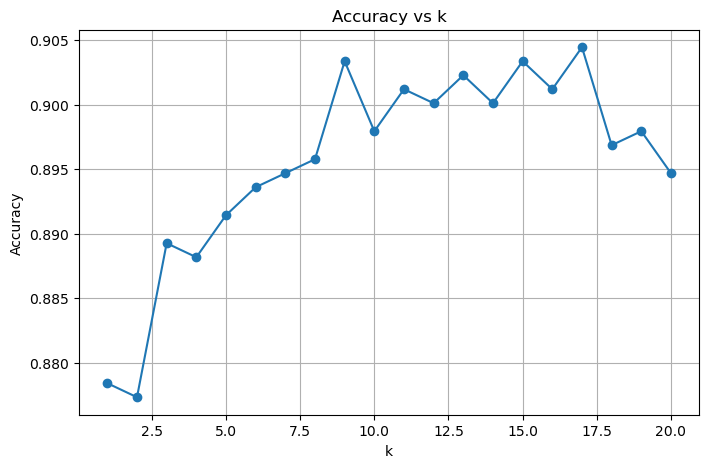

In [17]:
accuracy=[]

k_values=range(1,21)

for k in k_values:

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    accuracy.append(accuracy_score(y_test,y_pred))

plt.figure(figsize=(8,5))

plt.plot(k_values,accuracy,marker="o")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.title("Accuracy vs k")

plt.grid()

plt.show()

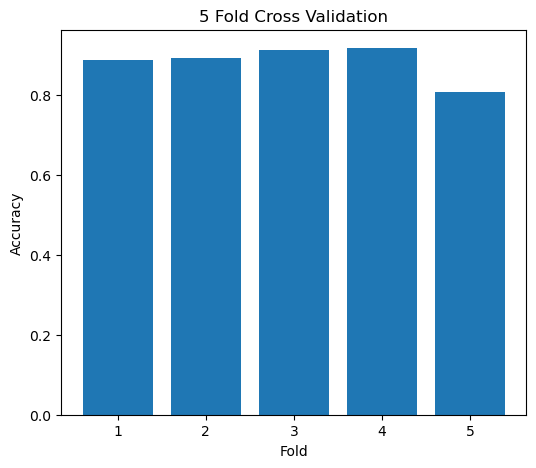

In [18]:
scores=cross_val_score(

    KNeighborsClassifier(),

    X,

    y,

    cv=5

)

plt.figure(figsize=(6,5))

plt.bar(range(1,6),scores)

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("5 Fold Cross Validation")

plt.show()

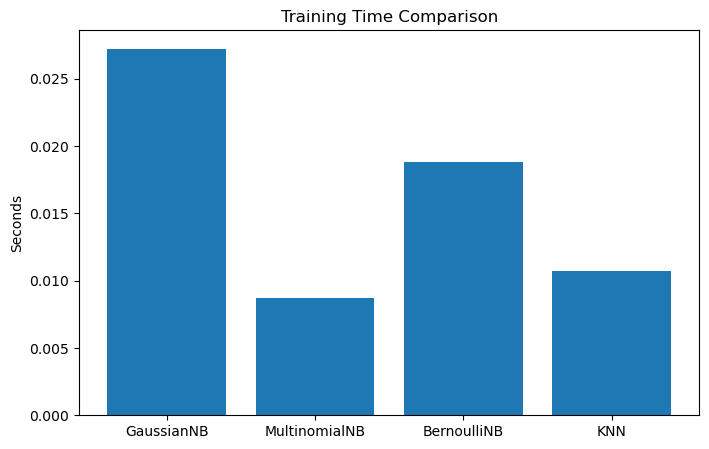

In [31]:
models=["GaussianNB","MultinomialNB","BernoulliNB","KNN"]

training_time=[

gaussian_train,

multinomial_train,

bernoulli_train,

knn_train

]

plt.figure(figsize=(8,5))

plt.bar(models,training_time)

plt.ylabel("Seconds")

plt.title("Training Time Comparison")

plt.show()

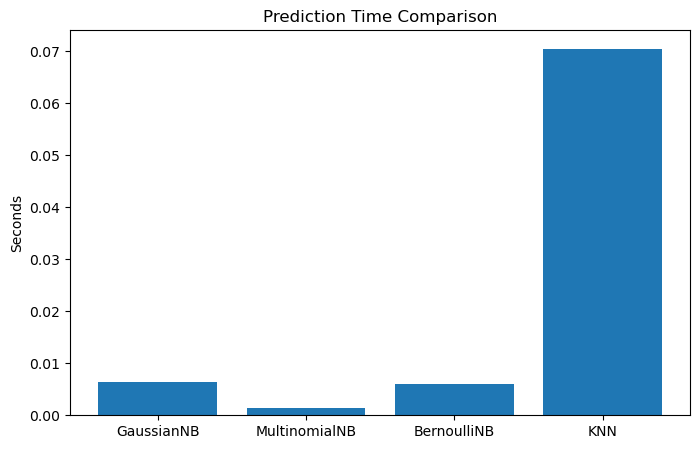

In [32]:
prediction_time=[

gaussian_predict,

multinomial_predict,

bernoulli_predict,

knn_predict

]

plt.figure(figsize=(8,5))

plt.bar(models,prediction_time)

plt.ylabel("Seconds")

plt.title("Prediction Time Comparison")

plt.show()

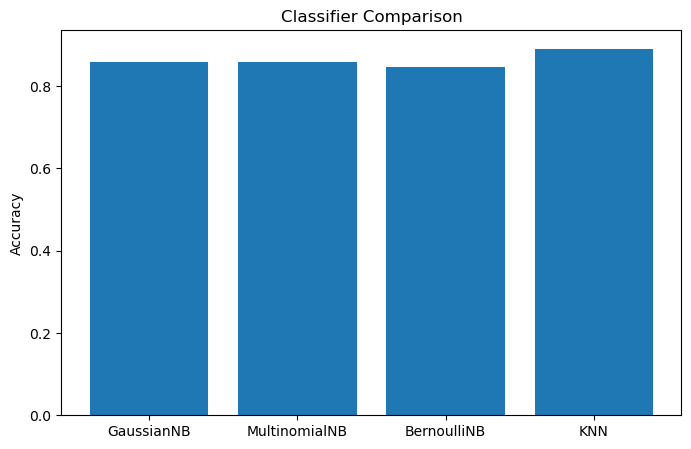

In [33]:
accuracy=[

gaussian_accuracy,

multinomial_accuracy,

bernoulli_accuracy,

knn_accuracy

]

plt.figure(figsize=(8,5))

plt.bar(models,accuracy)

plt.ylabel("Accuracy")

plt.title("Classifier Comparison")

plt.show()

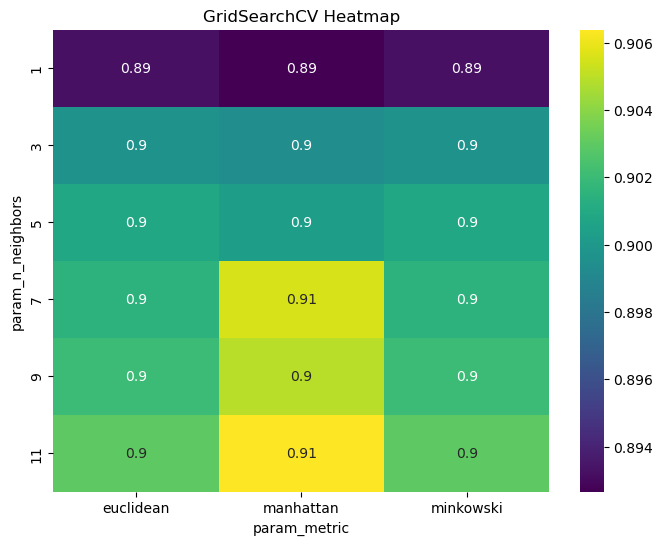

In [38]:
results=pd.DataFrame(grid.cv_results_)

pivot=results.pivot_table(

values="mean_test_score",

index="param_n_neighbors",

columns="param_metric"

)

plt.figure(figsize=(8,6))

sns.heatmap(

pivot,

annot=True,

cmap="viridis"

)

plt.title("GridSearchCV Heatmap")

plt.show()

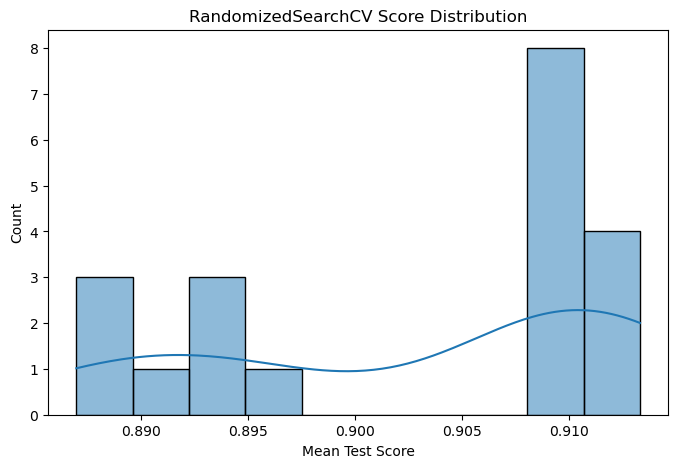

In [39]:
results=pd.DataFrame(random.cv_results_)

plt.figure(figsize=(8,5))

sns.histplot(

results["mean_test_score"],

bins=10,

kde=True

)

plt.title("RandomizedSearchCV Score Distribution")

plt.xlabel("Mean Test Score")

plt.show()